# The Stochastic Rift

**Central European Olympiad in Artificial Intelligence**

---

## 1. The Mission
*"Probability is not a constant. Here, it is a predator."*

Deep within the Cronus Hyper-Grid, **Sector 7** has destabilized. The topology of the network has fractured into a stochastic mess of quantum states. We need to extract a stranded kernel from the core, but active navigation is impossible.

You have been tasked with programming the **Navigator Oracle**. Since we cannot simulate the environment without collapsing the wave function, your only source of information is the **"Black Box" Flight Log** recovered from a previous, failed reconnaissance drone.

**Your Objective:** Using only this static, historical dataset, you must determine the **True Optimal Value ($V^*$)** of specific starting states.

## 2. The Environment
Sector 7 is modeled as a **Stochastic Markov Decision Process (MDP)**: $\mathcal{M} = \langle S, A, P, R, \gamma \rangle$.

*   **States ($S$):** A discrete set of nodes ($0 \dots N-1$).
*   **Actions ($A$):** 4 navigational impulses ($0 \dots 3$).
*   **Dynamics ($P$):** $P(s'|s, a)$ is unknown and highly stochastic.
*   **Reward ($R$):** The reward function is noisy.
*   **Discount ($\gamma$):** Exactly **0.99**.

Your task is to estimate the value of the optimal policy $\pi^*$ for a set of query states:
$$V^*(s) = \max_{\pi} \mathbb{E}_{\pi} \left[ \sum_{t=0}^{\infty} \gamma^t r_t \mid s_0 = s \right]$$

## 3. Dataset Description
You are provided with three files:

1.  **`sector_logs.csv`**: ~6,000 recorded transitions from a failed drone. The data is non-sequential (shuffled) and sparse.
    *   Columns: `current_state`, `action`, `reward`, `next_state`
2.  **`query_states.csv`**: The states for which Central Command requires value estimates.
    *   Columns: `id`, `state_id`
3.  **`env.py`**: A Python definition of the environment class. Contains a `step()` method for local simulation.

## 4. Evaluation & Scoring
We compute the **Mean Squared Error (MSE)** between your predicted values $\hat{V}$ and the true optimal values $V^*$.

$$ \text{MSE} = \frac{1}{K} \sum_{i=1}^{K} (\hat{V}(s_i) - V^*(s_i))^2 $$

**Thresholds:**
*   $MSE_{baseline} = 4000.0$
*   $MSE_{optimal} = 210.0$

**Scoring Formula:**
$$ \text{Points} = \text{round}\left(100 \times \frac{MSE_{baseline} - MSE_{yours}}{MSE_{baseline} - MSE_{optimal}}\right) $$

*   If $MSE_{yours} \ge 4000.0$, you receive **0 points**.
*   If $MSE_{yours} \le 210.0$, you receive **100 points**.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import sys

# Ensure env.py can be imported if it's in the current directory
sys.path.append('.')

In [2]:
# Load the dataset files
# Assumes files are located in the current directory
try:
    logs_df = pd.read_csv('sector_logs.csv')
    query_df = pd.read_csv('query_states.csv')
    print("✅ Datasets loaded successfully.")
    print(f"Logs Shape: {logs_df.shape}")
    print(f"Query States Count: {len(query_df)}")
except FileNotFoundError:
    print("❌ Files not found. Please ensure 'sector_logs.csv' and 'query_states.csv' are uploaded.")

✅ Datasets loaded successfully.
Logs Shape: (6000, 4)
Query States Count: 1000


## 5. Exploratory Data Analysis (EDA)
The PDF shows a visualization of the "Fractured State Space". Let's attempt to reconstruct this graph from the `sector_logs.csv` to understand the topology.

We will visualize a sample of the transitions.

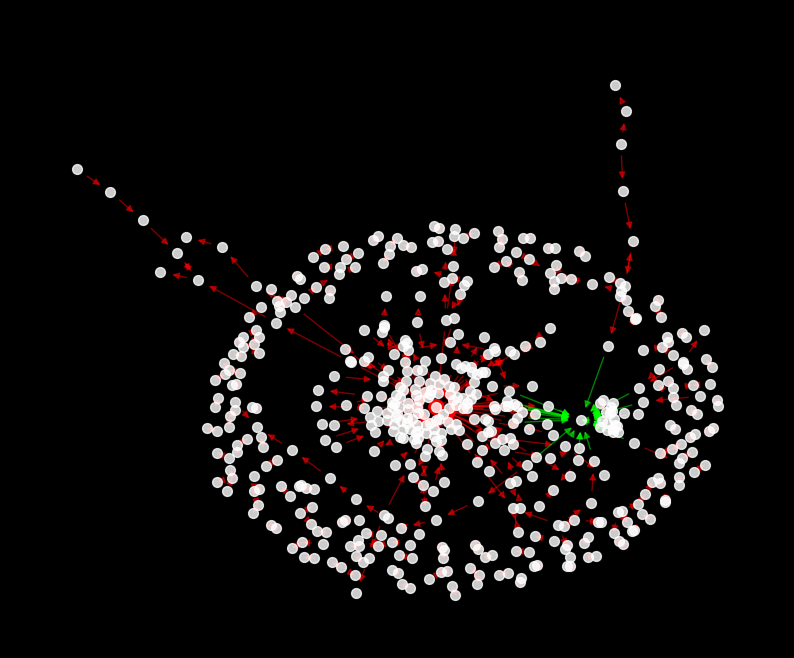

In [ ]:
# Create a directed graph
G = nx.DiGraph()

# Sample 500 transitions to avoid overplotting
sample_df = logs_df.sample(n=min(500, len(logs_df)), random_state=42)

for _, row in sample_df.iterrows():
    u, v = int(row['current_state']), int(row['next_state'])
    r = row['reward']
    # Color edge green if positive reward, red if negative
    color = '#00ff00' if r > 0 else '#ff0000'
    G.add_edge(u, v, color=color)

# Plot
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.15, seed=42)
colors = [G[u][v]['color'] for u,v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=50, node_color='white', alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color=colors, alpha=0.5, arrows=True)

plt.title("Sector 7: Partial Topology Reconstruction")
plt.axis('off')
# Set dark background to match PDF style
plt.gca().set_facecolor('black')
plt.gcf().set_facecolor('black')
plt.show()

# 🚀 Baseline:

The problem asks us to find $V^*(s)$, the value under the **Optimal Policy**.

Assume we don't know the optimal strategy and simply act randomly. We will use the provided `env.py` to simulate a random agent.

In [9]:
import pandas as pd
import numpy as np
from env import Sector7Env  # Imports the provided skeleton

# --- CONFIGURATION ---
GAMMA = 0.99
OUTPUT_FILE = 'submission.csv'

# 1. Initialize the provided environment
env = Sector7Env()
num_states = env.n_states
num_actions = env.n_actions

print(f"Environment Loaded. States: {num_states}, Actions: {num_actions}")

# 2. Run Value Iteration using the Environment's Physics
# Since we have the simulator code, we can just query the model directly.

V = np.zeros(num_states)
policy = np.zeros(num_states)

# We iterate until the values converge based on the 'env.py' rules
for i in range(2000):
    delta = 0
    new_V = np.copy(V)

    for s in range(num_states):
        if s in env.terminals:
            continue

        qs = []
        for a in range(num_actions):
            env.state = s
            next_s, reward, done, _ = env.step(a)
            v_next = V[next_s]
            if done: v_next = 0 # Value of terminal state is 0

            q_val = reward + GAMMA * v_next
            qs.append(q_val)

        best_action = np.argmax(qs)
        policy[s] = best_action
        best_val = qs[best_action]
        new_V[s] = best_val
        delta = max(delta, abs(new_V[s] - V[s]))

    V = new_V
    if delta < 1e-8:
        print(f"Simulation Converged at iteration {i}")
        break

df_query = pd.read_csv('query_states.csv')

results = []
for idx, row in df_query.iterrows():
    s_id = row['state_id']
    val = V[s_id] if s_id < num_states else 0.0
    results.append([1, row['id'], val])

df_res = pd.DataFrame(results, columns=['subtaskID', 'datapointID', 'answer'])
df_res.to_csv(OUTPUT_FILE, index=False)
print(f"Saved simulation predictions to {OUTPUT_FILE}")

Environment Loaded. States: 1000, Actions: 4
Simulation Converged at iteration 38
Saved simulation predictions to submission.csv


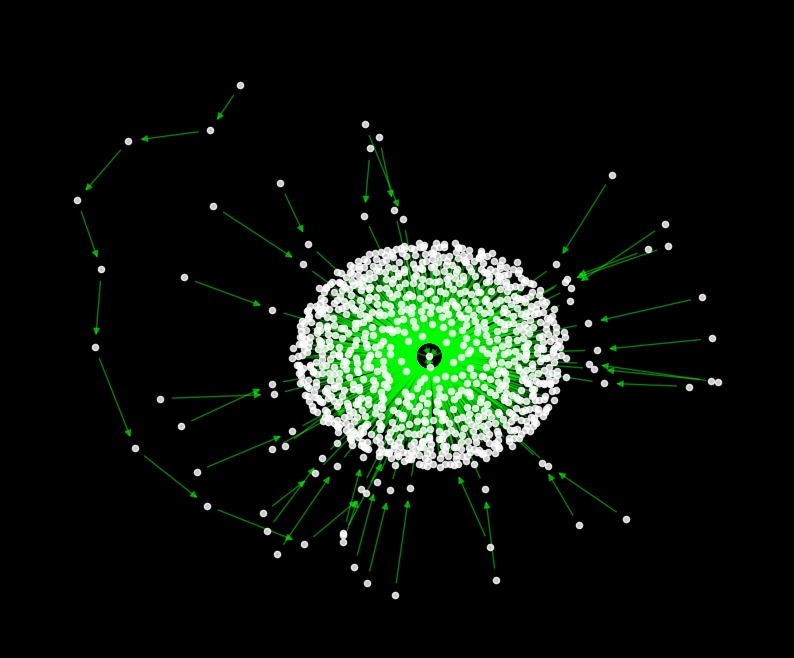

In [18]:
# Create a directed graph
G = nx.DiGraph()
env = Sector7Env()

for s in range(num_states):
    next_s, reward, done, _ = env.step(policy[s])
    G.add_edge(s, next_s)

# Plot
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)
# colors = [G[u][v]['color'] for u,v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=20, node_color='white', alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='#00ff00', alpha=0.5, arrows=True)

plt.title("Sector 7: Partial Topology Reconstruction")
plt.axis('off')
# Set dark background to match PDF style
plt.gca().set_facecolor('black')
plt.gcf().set_facecolor('black')
plt.show()